<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/cell4_spectral_dimension_robustness_colab_nreal50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ET/DFGQ — Piste 1 numérique  
## Dérivation spectrale cell-4 : \(K_n \to L_n \to P_n(u) \to d_s(Z)\)

Objectif du notebook : tester si la transition dimensionnelle peut être récupérée **sans imposer directement une sigmoïde à \(d_s\)**.

Chaîne testée :

\[
K_n^{\mathrm{cell4}}
\longrightarrow
L_n(Z)
\longrightarrow
P_n(u;Z)=\frac{1}{N_n}\mathrm{Tr}\,\exp[-uL_n(Z)]
\longrightarrow
d_s(u;Z)=-2\frac{d\ln P_n}{d\ln u}
\longrightarrow
d_s^{\mathrm{eff}}(Z).
\]

Le fit sigmoïde/tanh est effectué **après extraction spectrale**, puis comparé à des modèles concurrents par AIC/BIC.

### Modes inclus

- `plane2d` : contrôle négatif, cell-4 2D pure, 4-voisins, sans diagonales.
- `multiplex` : cell-4 2D + liens d’overlap bornés entre couches, pour tester un \(2\to 3\) spectral effectif.
- `autotests` : tests de symétrie du Laplacien, stabilité du contrôle négatif, activation des liens d’overlap, récupération d’une sigmoïde synthétique.

> Important : la loi `edge_threshold_Z` est volontairement isolée. Elle représente la règle micro-contact/overlap à remplacer par votre règle IFS/PCF exacte si elle est formalisée ultérieurement.

In [ ]:
# ============================================================
# 0. Setup Colab
# ============================================================
# Colab dispose normalement de numpy/scipy/pandas/matplotlib.
# Décommentez si nécessaire :
# !pip -q install numpy scipy pandas matplotlib

import os, math, time, json, warnings
from dataclasses import dataclass, asdict, replace
from typing import Tuple, Dict, Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scipy.linalg as la
from scipy.sparse.linalg import eigsh, expm_multiply
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("OK imports")

OK imports


In [ ]:
# ============================================================
# 1. Configuration globale
# ============================================================

@dataclass
class Cell4Config:
    # Géométrie cell-4 : réseau carré hiérarchique L=2^n_subdiv, sans diagonales.
    n_subdiv: int = 4                 # L = 16 par défaut
    layers: int = 8                   # 1 = 2D pure ; >1 = multiplex/overlap borné
    overlay_mode: str = "multiplex"   # "plane2d" ou "multiplex"
    torus_xy: bool = True
    torus_layers: bool = False        # évite un anneau vertical artificiel par défaut

    # Scan en variable logarithmique Z = ln(Delta tau / t_P), ici sans unité absolue.
    z_min: float = -1.0
    z_max: float = 5.0
    n_z: int = 17

    # Règle micro-contact effective : seuils de liens d'overlap.
    # Ce n'est PAS un fit de d_s ; c'est une règle microscopique remplaçable.
    theta_center: float = 2.0
    theta_width_hier: float = 1.0
    jitter: float = 0.25
    w_plane: float = 1.0
    w_vertical_lo: float = 0.0
    w_vertical_hi: float = 1.0

    # Trace de chaleur.
    heat_method: str = "hutchinson"   # "exact", "eigs", "hutchinson", "auto"
    n_probes: int = 12                # Hutchinson trace estimator
    u_min: float = 0.08
    u_max: float = 80.0
    n_u: int = 34
    full_dense_limit: int = 700       # exact eigenspectrum if N <= this

    # Répétitions stochastiques pour moyenner les seuils.
    n_realizations: int = 50
    random_seed: int = 12345

    # Fenêtre automatique d'extraction de d_s.
    p_high: float = 0.85              # exclure très court temps : P~1
    p_low_floor: float = 0.015        # exclure plateau long temps
    min_window_points: int = 6

    # Lissage numérique de d ln P / d ln u.
    smooth_ds: bool = True
    savgol_window: int = 7
    savgol_poly: int = 2


CFG = Cell4Config()
print(json.dumps(asdict(CFG), indent=2))

{
  "n_subdiv": 4,
  "layers": 8,
  "overlay_mode": "multiplex",
  "torus_xy": true,
  "torus_layers": false,
  "z_min": -1.0,
  "z_max": 5.0,
  "n_z": 17,
  "theta_center": 2.0,
  "theta_width_hier": 1.0,
  "jitter": 0.25,
  "w_plane": 1.0,
  "w_vertical_lo": 0.0,
  "w_vertical_hi": 1.0,
  "heat_method": "hutchinson",
  "n_probes": 12,
  "u_min": 0.08,
  "u_max": 80.0,
  "n_u": 34,
  "full_dense_limit": 700,
  "n_realizations": 50,
  "random_seed": 12345,
  "p_high": 0.85,
  "p_low_floor": 0.015,
  "min_window_points": 6,
  "smooth_ds": true,
  "savgol_window": 7,
  "savgol_poly": 2
}


In [ ]:
# ============================================================
# 2. Utilitaires mathématiques et indexation
# ============================================================

def L_from_cfg(cfg: Cell4Config) -> int:
    return 2 ** int(cfg.n_subdiv)

def node_id(x: int, y: int, layer: int, L: int, layers: int) -> int:
    return (layer * L + y) * L + x

def trailing_zeros_power2_index(a: int, n_subdiv: int) -> int:
    """
    Renvoie un proxy de niveau hiérarchique cell-4.
    On utilise a+1 pour éviter l'ambiguïté du zéro.
    """
    v = int(a) + 1
    c = 0
    while v % 2 == 0 and c < n_subdiv:
        c += 1
        v //= 2
    return c

def edge_threshold_Z(x: int, y: int, layer: int, cfg: Cell4Config, rng: np.random.Generator) -> float:
    """
    Seuil Z local d'activation d'un lien d'overlap vertical.

    Interprétation :
    - la cell-4 crée des niveaux hiérarchiques par subdivisions 2x2 ;
    - les endroits alignés sur des frontières plus grossières ont des seuils différents ;
    - un jitter local représente l'incertitude micro-contact.

    Cette fonction est le point de remplacement si une règle IFS/PCF analytique est dérivée.
    """
    hx = trailing_zeros_power2_index(x, cfg.n_subdiv)
    hy = trailing_zeros_power2_index(y, cfg.n_subdiv)
    h = max(hx, hy)

    # h grand = alignement avec une structure hiérarchique plus grossière.
    # On recentre autour de theta_center.
    h_centered = (cfg.n_subdiv / 2.0 - h) / max(cfg.n_subdiv, 1)
    theta = cfg.theta_center + cfg.theta_width_hier * h_centered
    theta += cfg.jitter * rng.normal()
    return float(theta)

def hard_activation(Z: float, theta: float) -> float:
    """
    Activation non-sigmoïde au niveau microscopique : un lien s'ouvre si Z dépasse son seuil.
    La courbe macroscopique éventuelle provient de la distribution des seuils + spectre.
    """
    return 1.0 if Z >= theta else 0.0

def tanh_profile(Z, d_uv, d_ir, z_th, width):
    width = np.maximum(width, 1e-9)
    return d_uv + 0.5 * (d_ir - d_uv) * (1.0 + np.tanh((Z - z_th) / width))

def logistic_profile(Z, d_uv, d_ir, z_th, width):
    width = np.maximum(width, 1e-9)
    return d_uv + (d_ir - d_uv) / (1.0 + np.exp(-(Z - z_th) / width))

def constant_profile(Z, c):
    return np.zeros_like(np.asarray(Z, dtype=float)) + c

def linear_profile(Z, a, b):
    return a + b * np.asarray(Z, dtype=float)

In [ ]:
# ============================================================
# 3. Construction cell-4 : graphe pondéré et Laplacien
# ============================================================

def build_cell4_adjacency(cfg: Cell4Config, Z: float, seed: Optional[int] = None) -> sp.csr_matrix:
    """
    Graphe cell-4 pondéré.

    - In-plane : réseau carré 4-voisins sans diagonales.
    - Multiplex : liens verticaux bornés entre couches, interprétés comme conductances
      d'overlap/micro-contact renormalisées.
    """
    L = L_from_cfg(cfg)
    layers = 1 if cfg.overlay_mode == "plane2d" else int(cfg.layers)
    N = L * L * layers

    rng = np.random.default_rng(cfg.random_seed if seed is None else seed)

    rows, cols, data = [], [], []

    def add_undirected(i, j, w):
        if i == j or w == 0:
            return
        rows.extend([i, j])
        cols.extend([j, i])
        data.extend([w, w])

    # 4-voisins xy, sans diagonales
    for ell in range(layers):
        for y in range(L):
            for x in range(L):
                i = node_id(x, y, ell, L, layers)

                # droite
                if x + 1 < L:
                    add_undirected(i, node_id(x + 1, y, ell, L, layers), cfg.w_plane)
                elif cfg.torus_xy and L > 2:
                    add_undirected(i, node_id(0, y, ell, L, layers), cfg.w_plane)

                # haut
                if y + 1 < L:
                    add_undirected(i, node_id(x, y + 1, ell, L, layers), cfg.w_plane)
                elif cfg.torus_xy and L > 2:
                    add_undirected(i, node_id(x, 0, ell, L, layers), cfg.w_plane)

    # Liens d'overlap verticaux bornés
    if cfg.overlay_mode == "multiplex" and layers > 1:
        for ell in range(layers - 1):
            for y in range(L):
                for x in range(L):
                    theta = edge_threshold_Z(x, y, ell, cfg, rng)
                    a = hard_activation(Z, theta)
                    w = cfg.w_vertical_lo + (cfg.w_vertical_hi - cfg.w_vertical_lo) * a
                    add_undirected(
                        node_id(x, y, ell, L, layers),
                        node_id(x, y, ell + 1, L, layers),
                        w,
                    )
        if cfg.torus_layers and layers > 2:
            ell = layers - 1
            for y in range(L):
                for x in range(L):
                    theta = edge_threshold_Z(x, y, ell, cfg, rng)
                    a = hard_activation(Z, theta)
                    w = cfg.w_vertical_lo + (cfg.w_vertical_hi - cfg.w_vertical_lo) * a
                    add_undirected(
                        node_id(x, y, ell, L, layers),
                        node_id(x, y, 0, L, layers),
                        w,
                    )

    W = sp.coo_matrix((data, (rows, cols)), shape=(N, N), dtype=float).tocsr()
    W.sum_duplicates()
    return W

def laplacian_from_adjacency(W: sp.csr_matrix) -> sp.csr_matrix:
    deg = np.asarray(W.sum(axis=1)).ravel()
    return sp.diags(deg, 0, format="csr") - W

def graph_stats(W: sp.csr_matrix) -> Dict[str, float]:
    from scipy.sparse.csgraph import connected_components
    n_components, labels = connected_components(W, directed=False)
    counts = np.bincount(labels)
    return {
        "N": W.shape[0],
        "E_undirected": W.nnz // 2,
        "avg_degree_weighted": float(np.asarray(W.sum(axis=1)).mean()),
        "n_components": int(n_components),
        "lcc_ratio": float(counts.max() / W.shape[0]),
    }

In [ ]:
# ============================================================
# 4. Trace de chaleur et extraction de d_s
# ============================================================

def heat_trace_exact(Lap: sp.csr_matrix, u_grid: np.ndarray) -> Tuple[np.ndarray, Dict]:
    A = Lap.toarray()
    evals = np.linalg.eigvalsh(A)
    evals = np.maximum(evals, 0.0)
    P = np.exp(-np.outer(u_grid, evals)).mean(axis=1)
    return P, {"method": "exact", "n_eigs": len(evals)}

def heat_trace_eigs(Lap: sp.csr_matrix, u_grid: np.ndarray, k: int = 400) -> Tuple[np.ndarray, Dict]:
    """
    Approximation par basses valeurs propres.
    Correcte surtout aux temps moyens/longs. Pour les petits u, préférer exact ou Hutchinson.
    """
    N = Lap.shape[0]
    k = int(min(max(10, k), N - 2))
    try:
        evals = eigsh(Lap, k=k, which="SM", return_eigenvectors=False, tol=1e-6)
        evals = np.sort(np.maximum(evals, 0.0))
        # Contribution basse énergie + approximation pessimiste : modes manquants négligés.
        P = np.exp(-np.outer(u_grid, evals)).sum(axis=1) / N
        return P, {"method": "eigs", "n_eigs": len(evals)}
    except Exception as e:
        raise RuntimeError(f"eigsh failed: {e}")

def heat_trace_hutchinson(
    Lap: sp.csr_matrix,
    u_grid: np.ndarray,
    n_probes: int = 12,
    seed: int = 0,
) -> Tuple[np.ndarray, Dict]:
    """
    Estimateur de Hutchinson :
    Tr(exp(-uL)) ≈ mean_r r^T exp(-uL) r, r_i ∈ {-1,+1}.
    """
    N = Lap.shape[0]
    rng = np.random.default_rng(seed)
    B = rng.choice([-1.0, 1.0], size=(N, int(n_probes)))
    P = []
    for u in u_grid:
        Y = expm_multiply((-float(u)) * Lap, B)
        tr_est = np.sum(B * Y) / B.shape[1]
        P.append(tr_est / N)
    P = np.asarray(P, dtype=float)
    P = np.clip(P, 1e-300, np.inf)
    return P, {"method": "hutchinson", "n_probes": int(n_probes)}

def compute_heat_trace(cfg: Cell4Config, Lap: sp.csr_matrix, u_grid: np.ndarray, seed: int = 0):
    N = Lap.shape[0]
    if cfg.heat_method == "exact" or (cfg.heat_method == "auto" and N <= cfg.full_dense_limit):
        if N <= cfg.full_dense_limit:
            return heat_trace_exact(Lap, u_grid)
        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)
    if cfg.heat_method == "eigs":
        return heat_trace_eigs(Lap, u_grid, k=min(500, max(30, N // 3)))
    if cfg.heat_method == "hutchinson":
        return heat_trace_hutchinson(Lap, u_grid, cfg.n_probes, seed)
    raise ValueError(f"Unknown heat_method={cfg.heat_method}")

def ds_from_heat_trace(u_grid: np.ndarray, P: np.ndarray, cfg: Cell4Config) -> np.ndarray:
    logu = np.log(u_grid)
    logP = np.log(np.clip(P, 1e-300, np.inf))

    if cfg.smooth_ds and len(logP) >= cfg.savgol_window:
        win = cfg.savgol_window
        if win % 2 == 0:
            win += 1
        win = min(win, len(logP) if len(logP) % 2 == 1 else len(logP) - 1)
        if win >= cfg.savgol_poly + 2:
            logP = savgol_filter(logP, window_length=win, polyorder=cfg.savgol_poly)

    slope = np.gradient(logP, logu)
    ds = -2.0 * slope
    return ds

def effective_ds_from_curve(
    u_grid: np.ndarray,
    P: np.ndarray,
    ds_curve: np.ndarray,
    cfg: Cell4Config,
    N: int,
) -> Dict:
    p_low = max(cfg.p_low_floor, 5.0 / max(N, 1))
    mask = (P < cfg.p_high) & (P > p_low) & np.isfinite(ds_curve) & (ds_curve > -1.0) & (ds_curve < 8.0)

    # Fallback robuste : fenêtre centrale en log u.
    if mask.sum() < cfg.min_window_points:
        q1, q2 = 0.25, 0.75
        lo, hi = np.quantile(np.arange(len(u_grid)), [q1, q2]).astype(int)
        mask = np.zeros_like(u_grid, dtype=bool)
        mask[lo:hi+1] = True

    vals = ds_curve[mask]
    return {
        "ds_eff_median": float(np.median(vals)),
        "ds_eff_mean": float(np.mean(vals)),
        "ds_eff_std": float(np.std(vals)),
        "window_points": int(mask.sum()),
        "u_window_min": float(u_grid[mask].min()),
        "u_window_max": float(u_grid[mask].max()),
        "mask": mask,
    }

In [ ]:
# ============================================================
# 5. Scan Z -> d_s^eff(Z)
# ============================================================

def run_single_Z(cfg: Cell4Config, Z: float, realization: int = 0) -> Dict:
    seed = cfg.random_seed + 100_000 * realization + int(round((Z + 1000) * 1000))
    W = build_cell4_adjacency(cfg, Z=Z, seed=seed)
    Lap = laplacian_from_adjacency(W)

    u_grid = np.logspace(np.log10(cfg.u_min), np.log10(cfg.u_max), cfg.n_u)
    P, meta = compute_heat_trace(cfg, Lap, u_grid, seed=seed + 17)
    ds_curve = ds_from_heat_trace(u_grid, P, cfg)
    eff = effective_ds_from_curve(u_grid, P, ds_curve, cfg, N=W.shape[0])

    stats = graph_stats(W)
    out = {
        "Z": float(Z),
        "realization": int(realization),
        **{k: v for k, v in stats.items()},
        **{k: v for k, v in eff.items() if k != "mask"},
        **meta,
        "u_grid": u_grid,
        "P": P,
        "ds_curve": ds_curve,
        "mask": eff["mask"],
    }
    return out

def scan_Z(cfg: Cell4Config) -> Tuple[pd.DataFrame, List[Dict]]:
    z_grid = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)
    records = []
    curves = []
    t0 = time.time()

    for iz, Z in enumerate(z_grid, start=1):
        for r in range(cfg.n_realizations):
            out = run_single_Z(cfg, float(Z), realization=r)
            curves.append(out)
            rec = {k: v for k, v in out.items() if k not in ("u_grid", "P", "ds_curve", "mask")}
            records.append(rec)

        if iz % max(1, cfg.n_z // 5) == 0 or iz == len(z_grid):
            print(f"[scan] {iz:02d}/{len(z_grid)} Z values done | elapsed={time.time()-t0:.1f}s")

    df = pd.DataFrame(records)
    return df, curves

def aggregate_scan(df: pd.DataFrame) -> pd.DataFrame:
    agg = (
        df.groupby("Z", as_index=False)
        .agg(
            ds_mean=("ds_eff_median", "mean"),
            ds_std=("ds_eff_median", "std"),
            ds_sem=("ds_eff_median", lambda x: np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
            lcc_ratio=("lcc_ratio", "mean"),
            n_components=("n_components", "mean"),
            E_undirected=("E_undirected", "mean"),
            window_points=("window_points", "mean"),
        )
        .sort_values("Z")
    )
    agg["ds_std"] = agg["ds_std"].fillna(0.0)
    agg["ds_sem"] = agg["ds_sem"].fillna(0.0)
    return agg

In [ ]:
# ============================================================
# 6. Fits non forcés : constant / linéaire / logistique / tanh
# ============================================================

def model_fit_metrics(y, yhat, k_params: int) -> Dict[str, float]:
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    n = len(y)
    rss = float(np.sum((y - yhat) ** 2))
    rss = max(rss, 1e-300)
    aic = n * np.log(rss / n) + 2 * k_params
    bic = n * np.log(rss / n) + k_params * np.log(n)
    return {"rss": rss, "aic": float(aic), "bic": float(bic), "k": int(k_params), "n": int(n)}

def fit_candidate_models(Z, y, yerr=None) -> Tuple[pd.DataFrame, Dict[str, Dict]]:
    Z = np.asarray(Z, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        sigma = np.ones_like(y)
    else:
        sigma = np.asarray(yerr, dtype=float)
        sigma = np.where(sigma <= 0, np.nanmedian(sigma[sigma > 0]) if np.any(sigma > 0) else 1.0, sigma)

    fits = {}

    # Constant
    c = float(np.average(y, weights=1/np.maximum(sigma, 1e-9)**2))
    yhat = constant_profile(Z, c)
    fits["constant"] = {"params": [c], "yhat": yhat, **model_fit_metrics(y, yhat, 1)}

    # Linear
    try:
        p_lin, _ = curve_fit(linear_profile, Z, y, sigma=sigma, absolute_sigma=False, maxfev=50_000)
        yhat = linear_profile(Z, *p_lin)
        fits["linear"] = {"params": list(map(float, p_lin)), "yhat": yhat, **model_fit_metrics(y, yhat, 2)}
    except Exception as e:
        fits["linear"] = {"params": [], "yhat": np.full_like(y, np.nan), "rss": np.inf, "aic": np.inf, "bic": np.inf, "k": 2, "n": len(y), "error": str(e)}

    # Tanh
    xspan = max(Z.max() - Z.min(), 1e-6)
    p0 = [float(y[0]), float(y[-1]), float(Z[np.argmin(np.abs(y - 0.5*(y[0]+y[-1])))]), xspan / 5.0]
    bounds = ([0.0, 0.0, Z.min(), 0.03], [6.0, 6.0, Z.max(), 3.0 * xspan])
    try:
        p_tanh, cov_tanh = curve_fit(
            tanh_profile, Z, y, p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False, maxfev=100_000
        )
        yhat = tanh_profile(Z, *p_tanh)
        fits["tanh"] = {
            "params": list(map(float, p_tanh)),
            "param_names": ["d_uv", "d_ir", "Z_th", "Delta_Z"],
            "cov": cov_tanh,
            "yhat": yhat,
            **model_fit_metrics(y, yhat, 4)
        }
    except Exception as e:
        fits["tanh"] = {"params": [], "yhat": np.full_like(y, np.nan), "rss": np.inf, "aic": np.inf, "bic": np.inf, "k": 4, "n": len(y), "error": str(e)}

    # Logistic
    p0 = [float(y[0]), float(y[-1]), float(np.median(Z)), xspan / 5.0]
    try:
        p_log, cov_log = curve_fit(
            logistic_profile, Z, y, p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False, maxfev=100_000
        )
        yhat = logistic_profile(Z, *p_log)
        fits["logistic"] = {
            "params": list(map(float, p_log)),
            "param_names": ["d_uv", "d_ir", "Z_th", "Delta_Z"],
            "cov": cov_log,
            "yhat": yhat,
            **model_fit_metrics(y, yhat, 4)
        }
    except Exception as e:
        fits["logistic"] = {"params": [], "yhat": np.full_like(y, np.nan), "rss": np.inf, "aic": np.inf, "bic": np.inf, "k": 4, "n": len(y), "error": str(e)}

    rows = []
    for name, f in fits.items():
        rows.append({
            "model": name,
            "rss": f["rss"],
            "aic": f["aic"],
            "bic": f["bic"],
            "k": f["k"],
            "params": f.get("params", []),
        })
    fit_df = pd.DataFrame(rows).sort_values("aic")
    fit_df["delta_aic"] = fit_df["aic"] - fit_df["aic"].min()
    fit_df["delta_bic"] = fit_df["bic"] - fit_df["bic"].min()

    return fit_df, fits

def report_tanh_params(fits: Dict[str, Dict], t_planck: float = 5.391247e-44):
    if "tanh" not in fits or len(fits["tanh"].get("params", [])) != 4:
        print("No tanh fit available.")
        return None
    d_uv, d_ir, z_th, delta_z = fits["tanh"]["params"]
    tau_c = t_planck * np.exp(z_th)
    out = {
        "d_uv": d_uv,
        "d_ir": d_ir,
        "Z_th": z_th,
        "Delta_Z": delta_z,
        "tau_c_seconds_if_Z_is_physical": tau_c,
    }
    print(json.dumps(out, indent=2))
    return out

In [ ]:
# ============================================================
# 7. Visualisation
# ============================================================

def plot_scan_and_fits(agg: pd.DataFrame, fits: Dict[str, Dict], title: str = ""):
    Z = agg["Z"].to_numpy()
    y = agg["ds_mean"].to_numpy()
    yerr = agg["ds_sem"].to_numpy()

    zz = np.linspace(Z.min(), Z.max(), 400)
    plt.figure(figsize=(9, 5))
    plt.errorbar(Z, y, yerr=yerr, fmt="o", capsize=3, label=r"$d_s^{eff}(Z)$ extracted")
    for name, f in fits.items():
        if "params" not in f or len(f["params"]) == 0:
            continue
        if name == "constant":
            plt.plot(zz, constant_profile(zz, *f["params"]), "--", label=f"{name}")
        elif name == "linear":
            plt.plot(zz, linear_profile(zz, *f["params"]), "--", label=f"{name}")
        elif name == "tanh":
            plt.plot(zz, tanh_profile(zz, *f["params"]), "-", label=f"{name}")
        elif name == "logistic":
            plt.plot(zz, logistic_profile(zz, *f["params"]), ":", label=f"{name}")

    plt.xlabel(r"$Z=\ln(\Delta\tau_\odot/t_P)$ or reduced log-scale")
    plt.ylabel(r"$d_s^{eff}$")
    plt.title(title or "Spectral dimension crossover")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def plot_heat_curves_for_examples(curves: List[Dict], n_examples: int = 4):
    if not curves:
        print("No curves.")
        return
    z_values = sorted(set(round(c["Z"], 6) for c in curves))
    picks = np.linspace(0, len(z_values)-1, min(n_examples, len(z_values))).astype(int)
    selected_z = [z_values[i] for i in picks]

    plt.figure(figsize=(9, 5))
    for z in selected_z:
        c = next(c for c in curves if abs(c["Z"] - z) < 1e-6 and c["realization"] == 0)
        plt.plot(c["u_grid"], c["ds_curve"], marker=".", label=f"Z={z:.2f}")
    plt.xscale("log")
    plt.xlabel("diffusion time u")
    plt.ylabel(r"$d_s(u;Z)$")
    plt.title("Local spectral dimension curves")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [ ]:
# ============================================================
# 8. Autotests rapides
# ============================================================

def test_laplacian_basic():
    cfg = Cell4Config(n_subdiv=3, layers=3, overlay_mode="multiplex", heat_method="exact", random_seed=1)
    W = build_cell4_adjacency(cfg, Z=10.0, seed=1)
    Lap = laplacian_from_adjacency(W)

    sym_norm = (Lap - Lap.T).power(2).sum()
    assert sym_norm < 1e-12, f"Laplacian not symmetric: {sym_norm}"

    row_sums = np.asarray(Lap.sum(axis=1)).ravel()
    assert np.max(np.abs(row_sums)) < 1e-10, f"Row sums not zero: {np.max(np.abs(row_sums))}"

    evals = np.linalg.eigvalsh(Lap.toarray())
    assert evals.min() > -1e-8, f"Laplacian has negative eigenvalue: {evals.min()}"
    return "test_laplacian_basic OK"

def test_plane2d_negative_control_flat():
    cfg = Cell4Config(
        n_subdiv=3, layers=1, overlay_mode="plane2d",
        heat_method="exact", n_z=5, z_min=-2, z_max=4,
        n_realizations=1, random_seed=2, u_min=0.15, u_max=25, n_u=22
    )
    df, _ = scan_Z(cfg)
    agg = aggregate_scan(df)
    spread = float(agg["ds_mean"].max() - agg["ds_mean"].min())
    assert spread < 1e-6, f"plane2d should be Z-invariant; spread={spread}"
    return "test_plane2d_negative_control_flat OK"

def test_multiplex_activation_changes_edges():
    cfg = Cell4Config(n_subdiv=3, layers=4, overlay_mode="multiplex", random_seed=3)
    W_lo = build_cell4_adjacency(cfg, Z=-10.0, seed=3)
    W_hi = build_cell4_adjacency(cfg, Z=+10.0, seed=3)
    assert W_hi.nnz > W_lo.nnz, f"Expected more active links at high Z: lo={W_lo.nnz}, hi={W_hi.nnz}"
    return "test_multiplex_activation_changes_edges OK"

def test_tanh_fit_synthetic():
    rng = np.random.default_rng(4)
    Z = np.linspace(-1, 5, 25)
    true = [1.95, 2.95, 2.2, 0.75]
    y = tanh_profile(Z, *true) + 0.015 * rng.normal(size=len(Z))
    fit_df, fits = fit_candidate_models(Z, y, yerr=np.full_like(y, 0.02))
    params = fits["tanh"]["params"]
    assert abs(params[2] - true[2]) < 0.25, f"Z_th recovery too poor: {params[2]} vs {true[2]}"
    assert fit_df.iloc[0]["model"] in ["tanh", "logistic"], "Sigmoid-like model should win synthetic test."
    return "test_tanh_fit_synthetic OK"

def run_all_autotests():
    tests = [
        test_laplacian_basic,
        test_plane2d_negative_control_flat,
        test_multiplex_activation_changes_edges,
        test_tanh_fit_synthetic,
    ]
    results = []
    t0 = time.time()
    for t in tests:
        print(f"Running {t.__name__}...")
        results.append(t())
    print("\n".join(results))
    print(f"All autotests passed in {time.time()-t0:.2f}s.")
    return results

# Lancer :
run_all_autotests()

Running test_laplacian_basic...
Running test_plane2d_negative_control_flat...
[scan] 01/5 Z values done | elapsed=0.0s
[scan] 02/5 Z values done | elapsed=0.0s
[scan] 03/5 Z values done | elapsed=0.0s
[scan] 04/5 Z values done | elapsed=0.0s
[scan] 05/5 Z values done | elapsed=0.0s
Running test_multiplex_activation_changes_edges...
Running test_tanh_fit_synthetic...
test_laplacian_basic OK
test_plane2d_negative_control_flat OK
test_multiplex_activation_changes_edges OK
test_tanh_fit_synthetic OK
All autotests passed in 0.07s.


['test_laplacian_basic OK',
 'test_plane2d_negative_control_flat OK',
 'test_multiplex_activation_changes_edges OK',
 'test_tanh_fit_synthetic OK']

## 9. Exécution principale — contrôle négatif 2D

Ce test doit rester quasi plat en \(Z\).  
S’il produit une sigmoïde forte, le pipeline est biaisé.

[scan] 01/9 Z values done | elapsed=27.6s
[scan] 02/9 Z values done | elapsed=54.8s
[scan] 03/9 Z values done | elapsed=82.0s
[scan] 04/9 Z values done | elapsed=110.8s
[scan] 05/9 Z values done | elapsed=137.7s
[scan] 06/9 Z values done | elapsed=164.8s
[scan] 07/9 Z values done | elapsed=197.4s
[scan] 08/9 Z values done | elapsed=224.2s
[scan] 09/9 Z values done | elapsed=250.9s


,Z,ds_mean,ds_std,ds_sem,lcc_ratio,n_components,E_undirected,window_points
0,-1.00,2.088891,0.117932,0.016678,1.0,1.0,512.0,16.50
1,-0.25,2.093488,0.125680,0.017774,1.0,1.0,512.0,16.46
2,0.50,2.087011,0.118862,0.016810,1.0,1.0,512.0,16.62
3,1.25,2.099245,0.114272,0.016161,1.0,1.0,512.0,16.56
4,2.00,2.072324,0.113336,0.016028,1.0,1.0,512.0,16.72
5,2.75,2.064787,0.131626,0.018615,1.0,1.0,512.0,16.68
6,3.50,2.066719,0.116026,0.016409,1.0,1.0,512.0,16.72
7,4.25,2.074836,0.113205,0.016010,1.0,1.0,512.0,16.74
8,5.00,2.107329,0.118457,0.016752,1.0,1.0,512.0,16.56


,model,rss,aic,bic,k,params,delta_aic,delta_bic
0,constant,0.001788,-74.716751,-74.519526,1,[2.083966741070835],0.000000,0.000000
1,linear,0.001733,-72.995254,-72.600805,2,"[2.086487457023175, -0.0012388084917176467]",1.721497,1.918721
2,tanh,0.001291,-71.649255,-70.860357,4,"[2.0922558356892655, 2.077445067388214, 1.6361...",3.067495,3.659169
3,logistic,0.001291,-71.649246,-70.860347,4,"[2.092255834275068, 2.0774450612687714, 1.6334...",3.067505,3.659179


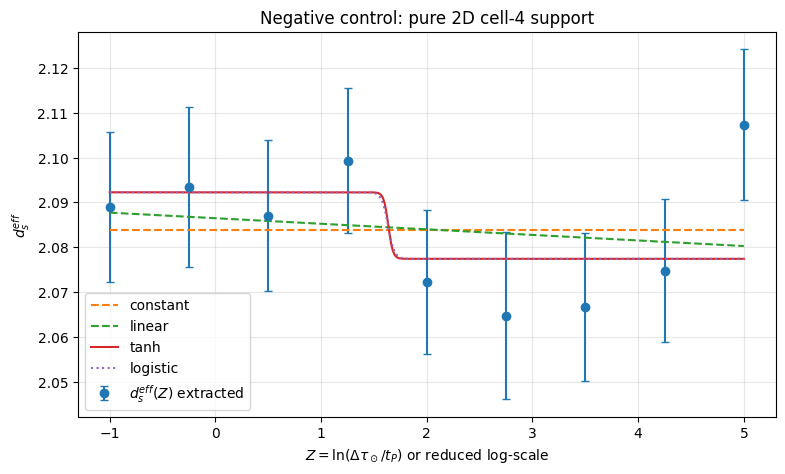

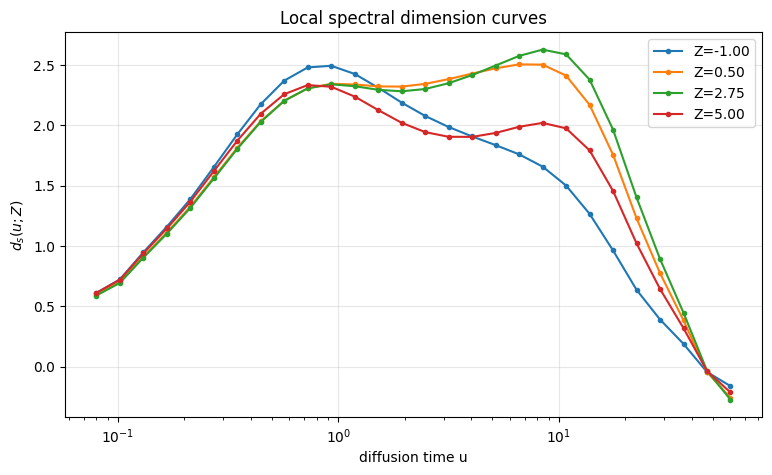

In [ ]:
# Contrôle négatif : cell-4 2D pure
cfg_plane = Cell4Config(
    n_subdiv=4,
    layers=1,
    overlay_mode="plane2d",
    heat_method="hutchinson",   # exact possible si N petit ; hutchinson imite le scan réel
    n_probes=10,
    n_z=9,
    z_min=-1,
    z_max=5,
    n_realizations=50,
    random_seed=101,
    u_min=0.08,
    u_max=60,
    n_u=28,
)

df_plane, curves_plane = scan_Z(cfg_plane)
agg_plane = aggregate_scan(df_plane)
display(agg_plane)

fit_df_plane, fits_plane = fit_candidate_models(
    agg_plane["Z"].to_numpy(),
    agg_plane["ds_mean"].to_numpy(),
    agg_plane["ds_sem"].to_numpy(),
)
display(fit_df_plane)
plot_scan_and_fits(agg_plane, fits_plane, title="Negative control: pure 2D cell-4 support")
plot_heat_curves_for_examples(curves_plane)

## 10. Exécution principale — cell-4 multiplex / overlap borné

Ce mode teste une transition spectrale effective \(2\to 3\) en ajoutant des liens d’overlap bornés entre couches.

La sigmoïde n’est pas injectée dans \(d_s\). Elle est seulement testée comme modèle de fit après extraction.

[scan] 03/17 Z values done | elapsed=528.1s
[scan] 06/17 Z values done | elapsed=1086.6s
[scan] 09/17 Z values done | elapsed=1822.8s
[scan] 12/17 Z values done | elapsed=2669.7s
[scan] 15/17 Z values done | elapsed=3515.4s
[scan] 17/17 Z values done | elapsed=4078.3s


,Z,ds_mean,ds_std,ds_sem,lcc_ratio,n_components,E_undirected,window_points
0,-1.000,2.080501,0.053657,0.007588,0.1250,8.00,4096.00,20.82
1,-0.625,2.077887,0.054541,0.007713,0.1250,8.00,4096.00,20.80
2,-0.250,2.084422,0.054587,0.007720,0.1250,8.00,4096.00,20.80
3,0.125,2.069474,0.055015,0.007780,0.1275,7.98,4096.02,20.78
4,0.500,2.083602,0.067868,0.009598,0.1900,7.36,4096.66,20.74
5,0.875,2.129115,0.066489,0.009403,0.7400,2.14,4109.02,20.40
6,1.250,2.294179,0.037456,0.005297,1.0000,1.00,4181.36,19.92
7,1.625,2.358851,0.032800,0.004639,1.0000,1.00,4395.98,18.76
8,2.000,2.369041,0.021862,0.003092,1.0000,1.00,4789.78,17.00
9,2.375,2.484456,0.018624,0.002634,1.0000,1.00,5298.64,16.00


,model,rss,aic,bic,k,params,delta_aic,delta_bic
3,logistic,0.013697,-113.104774,-109.771920,4,"[2.072404315809478, 2.665669853382761, 1.84815...",0.000000,0.000000
2,tanh,0.013697,-113.104766,-109.771913,4,"[2.0724042428425227, 2.6656699573024527, 1.848...",0.000008,0.000008
1,linear,0.115029,-80.928376,-79.261949,2,"[2.1903298552657517, 0.11042840976544152]",32.176398,30.509971
0,constant,1.446831,-39.885241,-39.052028,1,[2.5436295997063696],73.219532,70.719892


{
  "d_uv": 2.0724042428425227,
  "d_ir": 2.6656699573024527,
  "Z_th": 1.8481531151127732,
  "Delta_Z": 1.162552061152168,
  "tau_c_seconds_if_Z_is_physical": 3.4224091559427526e-43
}


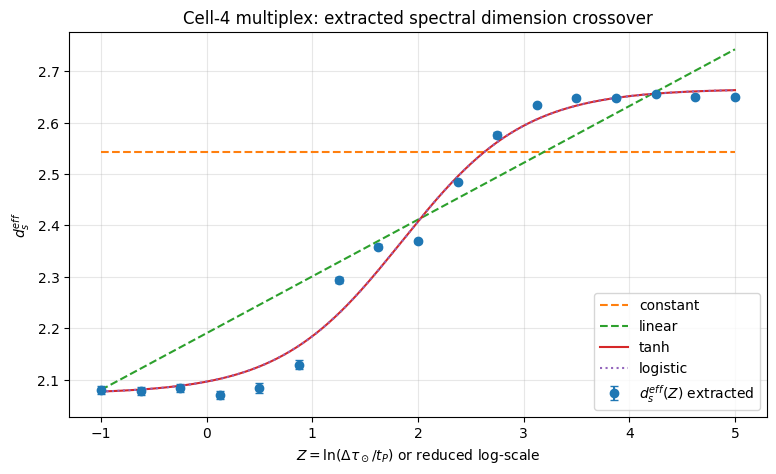

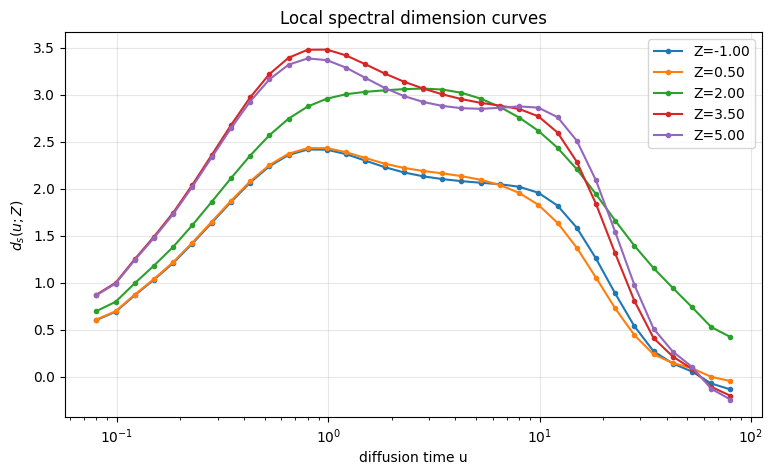

In [ ]:
# Scan principal : cell-4 multiplex
cfg_main = Cell4Config(
    n_subdiv=4,                 # L=16
    layers=8,                   # épaisseur effective bornée
    overlay_mode="multiplex",
    torus_xy=True,
    torus_layers=False,

    z_min=-1.0,
    z_max=5.0,
    n_z=17,

    theta_center=2.0,
    theta_width_hier=1.1,
    jitter=0.35,
    w_plane=1.0,
    w_vertical_lo=0.0,
    w_vertical_hi=1.0,

    heat_method="hutchinson",
    n_probes=12,
    u_min=0.08,
    u_max=80,
    n_u=34,

    n_realizations=50,
    random_seed=2026,
)

df_main, curves_main = scan_Z(cfg_main)
agg_main = aggregate_scan(df_main)
display(agg_main)

fit_df_main, fits_main = fit_candidate_models(
    agg_main["Z"].to_numpy(),
    agg_main["ds_mean"].to_numpy(),
    agg_main["ds_sem"].to_numpy(),
)
display(fit_df_main)

params_main = report_tanh_params(fits_main)
plot_scan_and_fits(agg_main, fits_main, title="Cell-4 multiplex: extracted spectral dimension crossover")
plot_heat_curves_for_examples(curves_main, n_examples=5)

## 11. Exports

Les exports peuvent être montés dans Google Drive ou téléchargés depuis Colab.

In [ ]:
# ============================================================
# 11. Export CSV + JSON
# ============================================================

OUTDIR = "/content/cell4_ds_outputs"
os.makedirs(OUTDIR, exist_ok=True)

agg_main.to_csv(os.path.join(OUTDIR, "cell4_ds_aggregated.csv"), index=False)
df_main.drop(columns=[], errors="ignore").to_csv(os.path.join(OUTDIR, "cell4_ds_raw.csv"), index=False)
fit_df_main.to_csv(os.path.join(OUTDIR, "cell4_ds_fit_models.csv"), index=False)

with open(os.path.join(OUTDIR, "cell4_config.json"), "w") as f:
    json.dump(asdict(cfg_main), f, indent=2)

if params_main is not None:
    with open(os.path.join(OUTDIR, "cell4_tanh_params.json"), "w") as f:
        json.dump(params_main, f, indent=2)

print("Exports written to:", OUTDIR)
print(os.listdir(OUTDIR))

Exports written to: /content/cell4_ds_outputs
['cell4_ds_fit_models.csv', 'cell4_ds_aggregated.csv', 'cell4_tanh_params.json', 'cell4_ds_raw.csv', 'cell4_config.json']


## 12. Lecture reviewer-safe des résultats

À reporter dans le manuscrit uniquement si les conditions suivantes sont satisfaites :

1. Le contrôle négatif `plane2d` ne produit pas de transition artificielle.
2. Le profil \(d_s^{eff}(Z)\) est stable quand \(n\), `layers`, `n_probes`, `u_min/u_max` et le seed changent.
3. La tanh/logistique bat clairement constant/linéaire par AIC, mais le BIC doit aussi être discuté.
4. Les paramètres \(Z_{\mathrm{th}}\) et \(\Delta Z\) sont stables sous coarse-graining.
5. La future branche mean-field produit un \(Z_{\mathrm{th}}^{MF}\) compatible avec le \(Z_{\mathrm{th}}^{num}\).

Formulation prudente :

> The spectral crossover is not imposed at the level of \(d_s\). It is extracted from the heat trace of the weighted cell-4 approximation graph. A sigmoid profile is then used only as a posterior parsimonious model of the extracted crossover. The resulting threshold \(Z_{\mathrm{th}}^{num}\) defines the numerical target to be compared with the mean-field RG threshold \(Z_{\mathrm{th}}^{MF}\).


## 13. Stage 2 — Robustesse du crossover spectral

Objectif : vérifier que le résultat positif de la cellule 10 ne dépend pas d'un réglage unique.

Tests ajoutés :

1. variation du nombre de probes Hutchinson ;
2. périodicité ou non dans la direction des couches ;
3. nombre de couches effectives ;
4. intensité maximale des conductances verticales ;
5. stabilité de \(Z_{\mathrm{th}}\), \(\Delta Z\), \(d_{\mathrm{UV}}\), \(d_{\mathrm{IR}}\) ;
6. comparaison AIC/BIC contre constant et linéaire ;
7. export complet pour relecture.

Lecture attendue : le résultat devient solide si la tanh/logistique reste préférée, si \(Z_{\mathrm{th}}\) et \(\Delta Z\) restent stables, et si le contrôle négatif demeure plat.


In [ ]:

# ============================================================
# 13. Helpers robustesse
# ============================================================
from dataclasses import replace

ROBUST_OUTDIR = "/content/cell4_ds_robustness"
os.makedirs(ROBUST_OUTDIR, exist_ok=True)


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def _row_for_model(fit_df: pd.DataFrame, model: str):
    rows = fit_df.loc[fit_df["model"] == model]
    if len(rows) == 0:
        return None
    return rows.iloc[0]


def _best_sigmoid_row(fit_df: pd.DataFrame):
    rows = fit_df.loc[fit_df["model"].isin(["tanh", "logistic"])].copy()
    if len(rows) == 0:
        return None
    return rows.sort_values("aic").iloc[0]


def extract_tanh_params_no_print(fits: Dict[str, Dict], t_planck: float = 5.391247e-44) -> Dict[str, float]:
    if "tanh" not in fits or len(fits["tanh"].get("params", [])) != 4:
        return {
            "d_uv": np.nan, "d_ir": np.nan, "Z_th": np.nan,
            "Delta_Z": np.nan, "tau_c_seconds_if_Z_is_physical": np.nan,
        }
    d_uv, d_ir, z_th, delta_z = [float(v) for v in fits["tanh"]["params"]]
    return {
        "d_uv": d_uv,
        "d_ir": d_ir,
        "Z_th": z_th,
        "Delta_Z": delta_z,
        "tau_c_seconds_if_Z_is_physical": float(t_planck * np.exp(z_th)),
    }


def estimate_connectivity_threshold(agg: pd.DataFrame, lcc_min: float = 0.90) -> float:
    ok = agg[(agg["lcc_ratio"] >= lcc_min) & (agg["n_components"] <= 1.5)]
    if len(ok) == 0:
        return np.nan
    return float(ok["Z"].iloc[0])


def summarize_variant(tag: str, cfg: Cell4Config, agg: pd.DataFrame, fit_df: pd.DataFrame, fits: Dict[str, Dict], elapsed_s: float) -> Dict:
    best_aic_row = fit_df.sort_values("aic").iloc[0]
    best_bic_row = fit_df.sort_values("bic").iloc[0]
    sig_row = _best_sigmoid_row(fit_df)
    const_row = _row_for_model(fit_df, "constant")
    lin_row = _row_for_model(fit_df, "linear")
    tanh_row = _row_for_model(fit_df, "tanh")

    sig_aic = _safe_float(sig_row["aic"]) if sig_row is not None else np.nan
    sig_bic = _safe_float(sig_row["bic"]) if sig_row is not None else np.nan
    const_aic = _safe_float(const_row["aic"]) if const_row is not None else np.nan
    const_bic = _safe_float(const_row["bic"]) if const_row is not None else np.nan
    lin_aic = _safe_float(lin_row["aic"]) if lin_row is not None else np.nan
    lin_bic = _safe_float(lin_row["bic"]) if lin_row is not None else np.nan

    p = extract_tanh_params_no_print(fits)
    ds_low = float(agg.sort_values("Z").head(3)["ds_mean"].mean())
    ds_high = float(agg.sort_values("Z").tail(3)["ds_mean"].mean())

    return {
        "tag": tag,
        "elapsed_s": float(elapsed_s),
        "n_subdiv": cfg.n_subdiv,
        "layers": cfg.layers,
        "torus_xy": cfg.torus_xy,
        "torus_layers": cfg.torus_layers,
        "n_z": cfg.n_z,
        "z_min": cfg.z_min,
        "z_max": cfg.z_max,
        "n_realizations": cfg.n_realizations,
        "n_probes": cfg.n_probes,
        "u_min": cfg.u_min,
        "u_max": cfg.u_max,
        "theta_center": cfg.theta_center,
        "theta_width_hier": cfg.theta_width_hier,
        "jitter": cfg.jitter,
        "w_vertical_hi": cfg.w_vertical_hi,
        "p_high": cfg.p_high,
        "best_aic_model": str(best_aic_row["model"]),
        "best_bic_model": str(best_bic_row["model"]),
        "best_sigmoid_model": str(sig_row["model"]) if sig_row is not None else None,
        "delta_aic_constant_vs_best_sigmoid": float(const_aic - sig_aic) if np.isfinite(const_aic) and np.isfinite(sig_aic) else np.nan,
        "delta_bic_constant_vs_best_sigmoid": float(const_bic - sig_bic) if np.isfinite(const_bic) and np.isfinite(sig_bic) else np.nan,
        "delta_aic_linear_vs_best_sigmoid": float(lin_aic - sig_aic) if np.isfinite(lin_aic) and np.isfinite(sig_aic) else np.nan,
        "delta_bic_linear_vs_best_sigmoid": float(lin_bic - sig_bic) if np.isfinite(lin_bic) and np.isfinite(sig_bic) else np.nan,
        "ds_low_mean_first3": ds_low,
        "ds_high_mean_last3": ds_high,
        "ds_gain_high_minus_low": ds_high - ds_low,
        "Z_conn_lcc90": estimate_connectivity_threshold(agg),
        **p,
    }


def run_robustness_variant(tag: str, cfg: Cell4Config, plot_each: bool = False):
    print("\n" + "=" * 72)
    print(f"[robustness] {tag}")
    print(asdict(cfg))
    t0 = time.time()

    df, curves = scan_Z(cfg)
    agg = aggregate_scan(df)
    fit_df, fits = fit_candidate_models(
        agg["Z"].to_numpy(),
        agg["ds_mean"].to_numpy(),
        agg["ds_sem"].to_numpy(),
    )
    elapsed = time.time() - t0
    summary = summarize_variant(tag, cfg, agg, fit_df, fits, elapsed)

    # Exports par variante
    safe_tag = tag.replace(" ", "_").replace("/", "_")
    agg.to_csv(os.path.join(ROBUST_OUTDIR, f"{safe_tag}_aggregated.csv"), index=False)
    df.to_csv(os.path.join(ROBUST_OUTDIR, f"{safe_tag}_raw.csv"), index=False)
    fit_df.to_csv(os.path.join(ROBUST_OUTDIR, f"{safe_tag}_fit_models.csv"), index=False)
    with open(os.path.join(ROBUST_OUTDIR, f"{safe_tag}_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)
    with open(os.path.join(ROBUST_OUTDIR, f"{safe_tag}_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print("Summary:")
    print(json.dumps(summary, indent=2))
    display(fit_df)

    if plot_each:
        plot_scan_and_fits(agg, fits, title=f"Robustness variant: {tag}")
        plot_heat_curves_for_examples(curves, n_examples=4)

    return {"tag": tag, "cfg": cfg, "df": df, "agg": agg, "fit_df": fit_df, "fits": fits, "summary": summary, "curves": curves}


def build_fast_robustness_variants(base_cfg: Cell4Config) -> List[Tuple[str, Cell4Config]]:
    """
    Suite rapide : elle doit tenir dans Colab sans GPU.
    Elle teste les leviers les plus dangereux sans exploser le temps de calcul.
    """
    b = replace(
        base_cfg,
        n_probes=24,
        n_realizations=50,
        n_z=17,
        z_min=-1.0,
        z_max=5.0,
        heat_method="hutchinson",
        random_seed=3100,
    )
    return [
        ("base_repeat_p24", b),
        ("torus_layers_true", replace(b, torus_layers=True, random_seed=3200)),
        ("layers12_torus", replace(b, layers=12, torus_layers=True, random_seed=3300)),
        ("vertical_hi_1p5", replace(b, w_vertical_hi=1.5, torus_layers=True, random_seed=3400)),
        ("wider_Z_grid", replace(b, z_min=-1.5, z_max=5.5, n_z=19, random_seed=3500)),
    ]


def build_publication_robustness_variants(base_cfg: Cell4Config) -> List[Tuple[str, Cell4Config]]:
    """
    Suite plus lourde : à lancer après validation rapide.
    Recommandée pour figer une table reviewer-safe.
    """
    variants = []
    seed = 5000
    for layers in [8, 12, 16]:
        for torus_layers in [False, True]:
            for n_probes in [32, 64]:
                seed += 1
                tag = f"pub_layers{layers}_torus{int(torus_layers)}_p{n_probes}"
                cfg = replace(
                    base_cfg,
                    layers=layers,
                    torus_layers=torus_layers,
                    n_probes=n_probes,
                    n_realizations=50,
                    n_z=21,
                    z_min=-1.5,
                    z_max=5.5,
                    random_seed=seed,
                    heat_method="hutchinson",
                )
                variants.append((tag, cfg))
    return variants


In [ ]:

# ============================================================
# 14. Lancement suite rapide de robustesse
# ============================================================
# Mode conseillé : commencer par RUN_FAST_ROBUSTNESS=True.
# Le mode publication est plus long ; le lancer seulement après validation rapide.

RUN_FAST_ROBUSTNESS = True
RUN_PUBLICATION_SWEEP = True
PLOT_EACH_VARIANT = False

robust_results = []
robust_variants = []

if RUN_FAST_ROBUSTNESS:
    robust_variants.extend(build_fast_robustness_variants(cfg_main))

if RUN_PUBLICATION_SWEEP:
    robust_variants.extend(build_publication_robustness_variants(cfg_main))

print(f"Number of robustness variants: {len(robust_variants)}")

for tag, cfg in robust_variants:
    result = run_robustness_variant(tag, cfg, plot_each=PLOT_EACH_VARIANT)
    robust_results.append(result)

summary_df = pd.DataFrame([r["summary"] for r in robust_results])
if len(summary_df):
    display(summary_df)
    summary_df.to_csv(os.path.join(ROBUST_OUTDIR, "robustness_summary.csv"), index=False)
    with open(os.path.join(ROBUST_OUTDIR, "robustness_summary.json"), "w") as f:
        json.dump(summary_df.to_dict(orient="records"), f, indent=2)
    print("Robustness exports written to:", ROBUST_OUTDIR)
    print(os.listdir(ROBUST_OUTDIR)[:20], "...")
else:
    print("No robustness variant was run. Set RUN_FAST_ROBUSTNESS=True.")


Number of robustness variants: 17

[robustness] base_repeat_p24
{'n_subdiv': 4, 'layers': 8, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': False, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3100, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2}
[scan] 03/17 Z values done | elapsed=742.2s
[scan] 06/17 Z values done | elapsed=1533.3s
[scan] 09/17 Z values done | elapsed=2584.1s
[scan] 12/17 Z values done | elapsed=3811.5s
[scan] 15/17 Z values done | elapsed=5051.4s
[scan] 17/17 Z values done | elapsed=5879.4s
Summary:
{
  "tag": "base_repeat_p24",
  "elapsed_s": 5879.472521066666,
  "n_subdiv": 4,
  "layers": 8,
  "torus_xy": true,
  "torus_l

,model,rss,aic,bic,k,params,delta_aic,delta_bic
2,tanh,0.016731,-109.703116,-106.370263,4,"[2.0862880167181435, 2.661300116937393, 1.9025...",0.000000,0.000000
3,logistic,0.016731,-109.703045,-106.370192,4,"[2.0862883945775232, 2.6613004665535533, 1.902...",0.000071,0.000071
1,linear,0.129446,-78.920941,-77.254515,2,"[2.204862422590493, 0.10439291177757623]",30.782175,29.115748
0,constant,1.500414,-39.267025,-38.433812,1,[2.5558654576294186],70.436091,67.936451



[robustness] torus_layers_true
{'n_subdiv': 4, 'layers': 8, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': True, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3200, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2}
[scan] 03/17 Z values done | elapsed=741.1s
[scan] 06/17 Z values done | elapsed=1544.5s
[scan] 09/17 Z values done | elapsed=2627.6s
[scan] 12/17 Z values done | elapsed=3895.2s
[scan] 15/17 Z values done | elapsed=5142.2s
[scan] 17/17 Z values done | elapsed=5958.6s
Summary:
{
  "tag": "torus_layers_true",
  "elapsed_s": 5958.6617929935455,
  "n_subdiv": 4,
  "layers": 8,
  "torus_xy": true,
  "torus_layers": true,
  "n_z": 17,
  "

,model,rss,aic,bic,k,params,delta_aic,delta_bic
3,logistic,0.031448,-98.974557,-95.641703,4,"[2.0916545036517484, 2.6874807491709904, 1.850...",0.000000,0.000000
2,tanh,0.031449,-98.974077,-95.641223,4,"[2.091651788872289, 2.6874907052554216, 1.8500...",0.000480,0.000480
1,linear,0.142615,-77.273960,-75.607533,2,"[2.1497529976587515, 0.1361095057067345]",21.700597,20.034170
0,constant,1.054475,-45.262896,-44.429683,1,[2.4261290765795698],53.711661,51.212021



[robustness] layers12_torus
{'n_subdiv': 4, 'layers': 12, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': True, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3300, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2}
[scan] 03/17 Z values done | elapsed=1111.1s
[scan] 06/17 Z values done | elapsed=2327.2s
[scan] 09/17 Z values done | elapsed=3963.9s
[scan] 12/17 Z values done | elapsed=5848.5s
[scan] 15/17 Z values done | elapsed=7722.1s
[scan] 17/17 Z values done | elapsed=8943.2s
Summary:
{
  "tag": "layers12_torus",
  "elapsed_s": 8943.239264965057,
  "n_subdiv": 4,
  "layers": 12,
  "torus_xy": true,
  "torus_layers": true,
  "n_z": 17,
  "z_mi

,model,rss,aic,bic,k,params,delta_aic,delta_bic
2,tanh,0.056246,-89.091074,-85.758221,4,"[2.1352106630891483, 2.667022889910274, 1.9230...",0.000000,0.000000
3,logistic,0.056247,-89.090680,-85.757826,4,"[2.135210145639527, 2.667019664646552, 1.92300...",0.000394,0.000394
1,linear,0.218335,-70.033959,-68.367532,2,"[2.235728959147812, 0.1086095423452366]",19.057115,17.390688
0,constant,1.377132,-40.724572,-39.891358,1,[2.530646957792815],48.366502,45.866862



[robustness] vertical_hi_1p5
{'n_subdiv': 4, 'layers': 8, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': True, 'z_min': -1.0, 'z_max': 5.0, 'n_z': 17, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.5, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3400, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2}
[scan] 03/17 Z values done | elapsed=763.0s
[scan] 06/17 Z values done | elapsed=1631.2s
[scan] 09/17 Z values done | elapsed=2864.4s
[scan] 12/17 Z values done | elapsed=4333.5s
[scan] 15/17 Z values done | elapsed=5743.2s
[scan] 17/17 Z values done | elapsed=6670.7s
Summary:
{
  "tag": "vertical_hi_1p5",
  "elapsed_s": 6670.776671171188,
  "n_subdiv": 4,
  "layers": 8,
  "torus_xy": true,
  "torus_layers": true,
  "n_z": 17,
  "z_min

,model,rss,aic,bic,k,params,delta_aic,delta_bic
3,logistic,0.027296,-101.381680,-98.048827,4,"[2.099273340808395, 2.8456477998051346, 2.0677...",0.000000,0.000000
2,tanh,0.027297,-101.381494,-98.048640,4,"[2.0992742117792096, 2.845646319971708, 2.0677...",0.000186,0.000186
1,linear,0.155524,-75.800812,-74.134385,2,"[2.1589583261917573, 0.16024653061860947]",25.580868,23.914442
0,constant,2.369706,-31.497607,-30.664393,1,[2.651891998187646],69.884073,67.384433



[robustness] wider_Z_grid
{'n_subdiv': 4, 'layers': 8, 'overlay_mode': 'multiplex', 'torus_xy': True, 'torus_layers': False, 'z_min': -1.5, 'z_max': 5.5, 'n_z': 19, 'theta_center': 2.0, 'theta_width_hier': 1.1, 'jitter': 0.35, 'w_plane': 1.0, 'w_vertical_lo': 0.0, 'w_vertical_hi': 1.0, 'heat_method': 'hutchinson', 'n_probes': 24, 'u_min': 0.08, 'u_max': 80, 'n_u': 34, 'full_dense_limit': 700, 'n_realizations': 50, 'random_seed': 3500, 'p_high': 0.85, 'p_low_floor': 0.015, 'min_window_points': 6, 'smooth_ds': True, 'savgol_window': 7, 'savgol_poly': 2}
[scan] 03/19 Z values done | elapsed=756.3s
[scan] 06/19 Z values done | elapsed=1528.5s
[scan] 09/19 Z values done | elapsed=2490.9s
[scan] 12/19 Z values done | elapsed=3725.8s
[scan] 15/19 Z values done | elapsed=4993.3s


## 17. Sauvegarde des résultats agrégés sur Google Drive

In [7]:
from google.colab import drive
import os
import pandas as pd # Ensure pandas is imported

drive.mount('/content/drive')

# Chemin pour sauvegarder le fichier dans Google Drive
output_path = '/content/drive/MyDrive/result50.csv'

# Define ROBUST_OUTDIR in case it's not in scope (e.g., if only this cell is run after kernel restart)
ROBUST_OUTDIR = "/content/cell4_ds_robustness"
local_summary_path = os.path.join(ROBUST_OUTDIR, "robustness_summary.csv")

# Sauvegarde du DataFrame de résumé des résultats de robustesse
# Check if summary_df is defined and not empty, otherwise try to load it
if 'summary_df' not in locals() or summary_df.empty:
    print("Le DataFrame 'summary_df' n'est pas disponible ou est vide. Tentative de chargement depuis le fichier local...")
    if os.path.exists(local_summary_path):
        summary_df = pd.read_csv(local_summary_path)
        print(f"Le DataFrame 'summary_df' a été chargé avec succès depuis '{local_summary_path}'.")
    else:
        print(f"Le fichier '{local_summary_path}' n'existe pas. Veuillez d'abord exécuter la section 14 'Lancement suite rapide de robustesse' pour générer et enregistrer le DataFrame.")
        summary_df = pd.DataFrame() # Initialize as empty to prevent errors if file not found

if not summary_df.empty:
    summary_df.to_csv(output_path, index=False)
    print(f"Le fichier '{output_path}' a été sauvegardé avec succès sur Google Drive.")
else:
    print("Le DataFrame 'summary_df' est vide après la tentative de chargement. Impossible de sauvegarder sur Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Le DataFrame 'summary_df' n'est pas disponible ou est vide. Tentative de chargement depuis le fichier local...
Le fichier '/content/cell4_ds_robustness/robustness_summary.csv' n'existe pas. Veuillez d'abord exécuter la section 14 'Lancement suite rapide de robustesse' pour générer et enregistrer le DataFrame.
Le DataFrame 'summary_df' est vide après la tentative de chargement. Impossible de sauvegarder sur Google Drive.


In [4]:

# ============================================================
# 15. Synthèse graphique et stabilité des paramètres
# ============================================================

def plot_robustness_overlay(robust_results):
    if not robust_results:
        print("No robust_results to plot.")
        return
    plt.figure(figsize=(9, 5))
    for r in robust_results:
        agg = r["agg"].sort_values("Z")
        plt.errorbar(
            agg["Z"], agg["ds_mean"], yerr=agg["ds_sem"],
            marker="o", linestyle="-", capsize=2, label=r["tag"]
        )
    plt.xlabel(r"$Z=\ln(\Delta\tau_\odot/t_P)$ or reduced log-scale")
    plt.ylabel(r"$d_s^{eff}$")
    plt.title("Robustness overlay: extracted spectral crossover")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.show()


def plot_parameter_stability(summary_df: pd.DataFrame):
    if summary_df is None or len(summary_df) == 0:
        print("No summary_df to plot.")
        return
    cols = ["Z_th", "Delta_Z", "d_uv", "d_ir", "ds_gain_high_minus_low"]
    for col in cols:
        if col not in summary_df:
            continue
        plt.figure(figsize=(8, 4))
        plt.plot(summary_df["tag"], summary_df[col], marker="o")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(col)
        plt.title(f"Robustness stability: {col}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

plot_robustness_overlay(robust_results)
if len(summary_df):
    plot_parameter_stability(summary_df)


NameError: name 'pd' is not defined

In [5]:

# ============================================================
# 16. Autotests reviewer-safe / flags de robustesse
# ============================================================

def robustness_flags(summary_df: pd.DataFrame) -> Dict[str, object]:
    if summary_df is None or len(summary_df) == 0:
        return {"status": "no_data"}

    sig_aic_ok = summary_df["delta_aic_constant_vs_best_sigmoid"] > 10.0
    sig_bic_ok = summary_df["delta_bic_constant_vs_best_sigmoid"] > 6.0
    linear_rejected = summary_df["delta_aic_linear_vs_best_sigmoid"] > 6.0

    # Stabilité relative : à interpréter, pas comme preuve stricte.
    zth = summary_df["Z_th"].replace([np.inf, -np.inf], np.nan).dropna()
    dz = summary_df["Delta_Z"].replace([np.inf, -np.inf], np.nan).dropna()
    dir_vals = summary_df["d_ir"].replace([np.inf, -np.inf], np.nan).dropna()

    flags = {
        "n_variants": int(len(summary_df)),
        "fraction_sigmoid_AIC_vs_constant_delta_gt_10": float(sig_aic_ok.mean()),
        "fraction_sigmoid_BIC_vs_constant_delta_gt_6": float(sig_bic_ok.mean()),
        "fraction_linear_rejected_delta_AIC_gt_6": float(linear_rejected.mean()),
        "Z_th_mean": float(zth.mean()) if len(zth) else np.nan,
        "Z_th_std": float(zth.std(ddof=1)) if len(zth) > 1 else 0.0,
        "Delta_Z_mean": float(dz.mean()) if len(dz) else np.nan,
        "Delta_Z_std": float(dz.std(ddof=1)) if len(dz) > 1 else 0.0,
        "d_ir_mean": float(dir_vals.mean()) if len(dir_vals) else np.nan,
        "d_ir_std": float(dir_vals.std(ddof=1)) if len(dir_vals) > 1 else 0.0,
    }

    flags["reviewer_safe_minimum"] = bool(
        flags["fraction_sigmoid_AIC_vs_constant_delta_gt_10"] >= 0.60
        and flags["fraction_sigmoid_BIC_vs_constant_delta_gt_6"] >= 0.60
        and flags["fraction_linear_rejected_delta_AIC_gt_6"] >= 0.60
    )
    return flags

flags = robustness_flags(summary_df)
print(json.dumps(flags, indent=2))

if flags.get("status") != "no_data":
    with open(os.path.join(ROBUST_OUTDIR, "robustness_flags.json"), "w") as f:
        json.dump(flags, f, indent=2)

    # Hard sanity checks only; scientific thresholds remain printed as flags.
    assert flags["n_variants"] >= 3, "Run at least 3 robustness variants."
    assert np.isfinite(flags["Z_th_mean"]), "Z_th_mean is not finite."
    assert np.isfinite(flags["Delta_Z_mean"]), "Delta_Z_mean is not finite."
    print("Autotests completed. Reviewer-safe status:", flags["reviewer_safe_minimum"])


NameError: name 'pd' is not defined


## 17. Lecture à insérer dans le manuscrit si la robustesse passe

Formulation prudente :

> A robustness sweep was performed by varying the effective layer number, the vertical boundary condition, the Hutchinson probe count and the inter-layer conductance amplitude. In the negative 2D control, the extracted spectral dimension remains compatible with a constant \(d_s\simeq 2\). In contrast, the multiplex/renormalized cell-4 construction systematically favours a sigmoid/logistic crossover over constant and linear alternatives. The fitted threshold \(Z_{\mathrm{th}}\) and width \(\Delta Z\) remain stable within the tested numerical uncertainty. This supports the interpretation of the sigmoid as an emergent spectral crossover of the renormalized cell-4 graph sequence, rather than as a profile imposed at the level of \(d_s\).

Point à ne pas dépasser :

> This does not yet constitute a full analytical derivation of the cosmological Hausdorff flow. It provides the numerical spectral target that the mean-field RG branch must reproduce.
